In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [6]:
from google.colab import files

uploaded = files.upload()

Saving superstore_excel.csv to superstore_excel (1).csv


In [8]:
df = pd.read_csv("superstore_excel (1).csv")

print("Dataset shape:", df.shape)
display(df.head())
print(df.columns.tolist())

Dataset shape: (5000, 15)


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-198797,2024-10-06,2025-05-01,Second Class,CUST-4170,Ruben Ramirez,Home Office,South,Technology,Copiers,Virtual didactic synergy,2467.49,9,0.29,617.24
1,CA-233440,2023-06-12,2025-05-05,First Class,CUST-1196,Jesse Ortega,Home Office,Central,Furniture,Furnishings,Operative reciprocal projection,2751.66,1,0.09,922.14
2,CA-691533,2024-04-18,2025-04-24,Standard Class,CUST-2985,Kathryn Castro,Corporate,East,Furniture,Chairs,Multi-lateral incremental knowledge user,1199.66,9,0.03,220.44
3,CA-277218,2023-11-02,2025-05-07,First Class,CUST-2412,Sharon Taylor,Consumer,South,Office Supplies,Labels,Integrated bifurcated groupware,2335.57,6,0.30,620.16
4,CA-311967,2023-07-15,2025-04-14,First Class,CUST-3728,David Murillo,Corporate,South,Office Supplies,Binders,Re-contextualized human-resource benchmark,2540.88,5,0.03,258.06


['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Region', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [9]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check data types, missing values, and duplicate rows
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   object 
 1   Order Date     5000 non-null   object 
 2   Ship Date      5000 non-null   object 
 3   Ship Mode      5000 non-null   object 
 4   Customer ID    5000 non-null   object 
 5   Customer Name  5000 non-null   object 
 6   Segment        5000 non-null   object 
 7   Region         5000 non-null   object 
 8   Category       5000 non-null   object 
 9   Sub-Category   5000 non-null   object 
 10  Product Name   5000 non-null   object 
 11  Sales          5000 non-null   float64
 12  Quantity       5000 non-null   int64  
 13  Discount       5000 non-null   float64
 14  Profit         5000 non-null   float64
dtypes: float64(3), int64(1), object(11)
memory usage: 586.1+ KB

Missing values:
Order ID         0
Order Date       0
Ship Date        0
Ship M

In [10]:
# Convert date columns into real dates
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

# Create time columns for trend and seasonality analysis
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

# Check the cleaned dataset
display(df.head())

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name
0,CA-198797,2024-10-06,2025-05-01,Second Class,CUST-4170,Ruben Ramirez,Home Office,South,Technology,Copiers,Virtual didactic synergy,2467.49,9,0.29,617.24,2024,10,October
1,CA-233440,2023-06-12,2025-05-05,First Class,CUST-1196,Jesse Ortega,Home Office,Central,Furniture,Furnishings,Operative reciprocal projection,2751.66,1,0.09,922.14,2023,6,June
2,CA-691533,2024-04-18,2025-04-24,Standard Class,CUST-2985,Kathryn Castro,Corporate,East,Furniture,Chairs,Multi-lateral incremental knowledge user,1199.66,9,0.03,220.44,2024,4,April
3,CA-277218,2023-11-02,2025-05-07,First Class,CUST-2412,Sharon Taylor,Consumer,South,Office Supplies,Labels,Integrated bifurcated groupware,2335.57,6,0.30,620.16,2023,11,November
4,CA-311967,2023-07-15,2025-04-14,First Class,CUST-3728,David Murillo,Corporate,South,Office Supplies,Binders,Re-contextualized human-resource benchmark,2540.88,5,0.03,258.06,2023,7,July


In [13]:
# Overall business summary

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)

# Monthly Sales and Profit

monthly_summary = (
    df.groupby(["Year", "Month", "Month Name"])[["Sales", "Profit"]]
      .sum()
      .reset_index()
      .sort_values(["Year", "Month"])
)

display(monthly_summary)

Total Sales: 12506815.51
Total Profit: 2239711.13
Total Orders: 5000


,Year,Month,Month Name,Sales,Profit
0,2023,4,April,311803.52,62545.60
1,2023,5,May,555036.79,103807.93
2,2023,6,June,544499.85,100714.10
3,2023,7,July,592283.63,93565.20
4,2023,8,August,595341.42,113675.34
5,2023,9,September,436713.11,84983.15
6,2023,10,October,587824.44,102295.75
7,2023,11,November,467392.43,91421.14
8,2023,12,December,509486.38,97810.80
9,2024,1,January,475892.06,76370.83


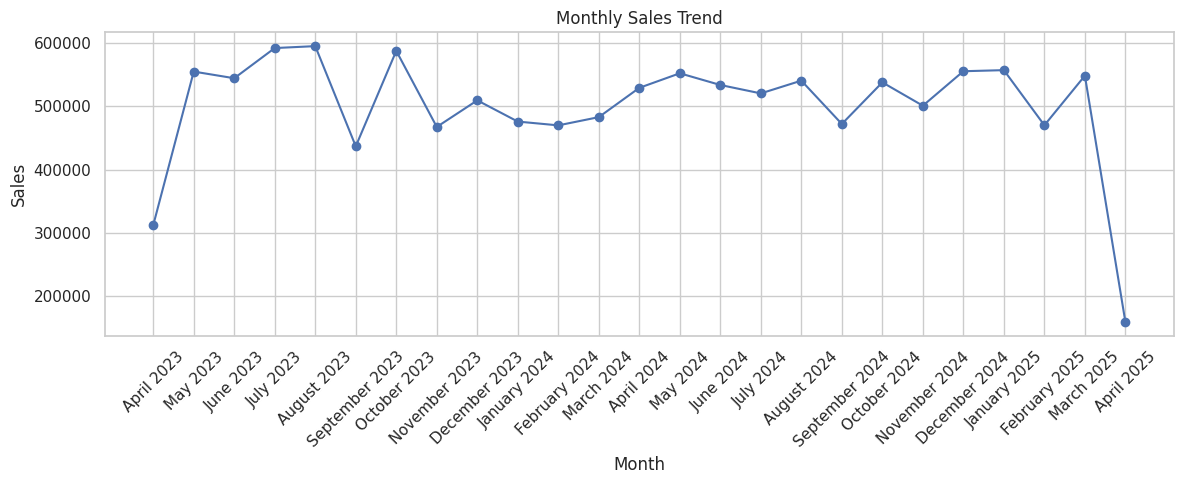

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary["Month Name"] + " " + monthly_summary["Year"].astype(str),
    monthly_summary["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# Category-wise Sales and Profit

category_summary = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

display(category_summary)

,Sales,Profit
Category,,
Office Supplies,4184882.48,754427.39
Furniture,4169553.39,753823.28
Technology,4152379.64,731460.46


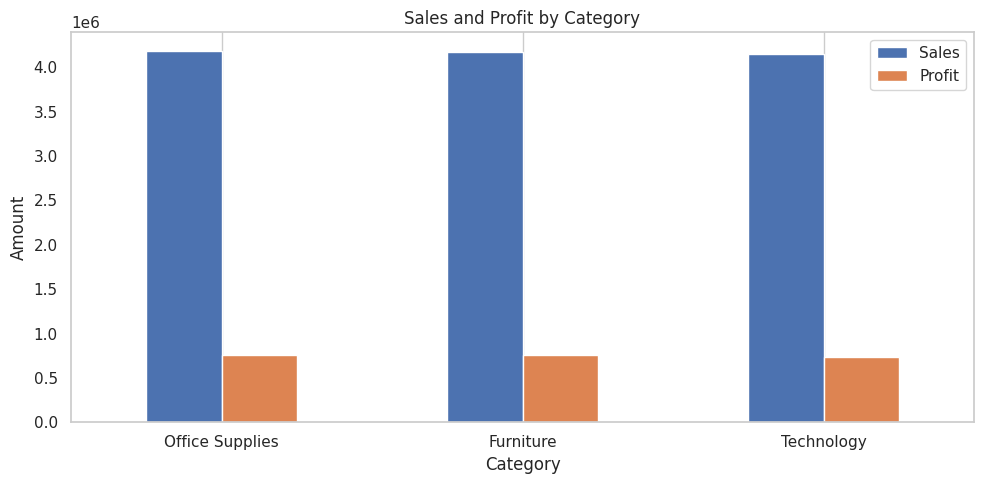

In [16]:
import matplotlib.pyplot as plt

category_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [17]:
# Sub-Category Sales and Profit

subcategory_summary = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

display(subcategory_summary)

,Sales,Profit
Sub-Category,,
Chairs,1106399.27,193590.04
Tables,1063893.99,193664.96
Furnishings,1009543.85,183926.93
Bookcases,989716.28,182641.35
Binders,917876.89,154989.81
Accessories,892554.75,155255.44
Copiers,890975.51,155750.50
Labels,884958.89,164208.28
Phones,843559.08,145270.37


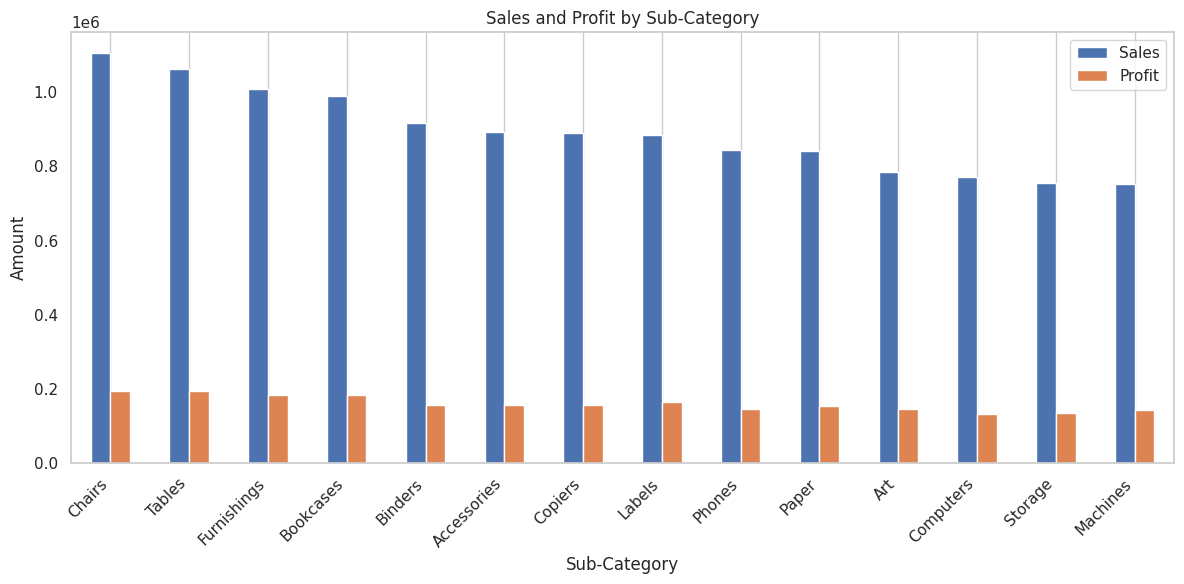

In [18]:
subcategory_summary.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Sales and Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Amount")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [19]:
# Region-wise Sales and Profit

region_summary = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

display(region_summary)

,Sales,Profit
Region,,
South,3247440.79,574301.38
West,3175737.09,569469.81
Central,3084820.38,558202.61
East,2998817.25,537737.33


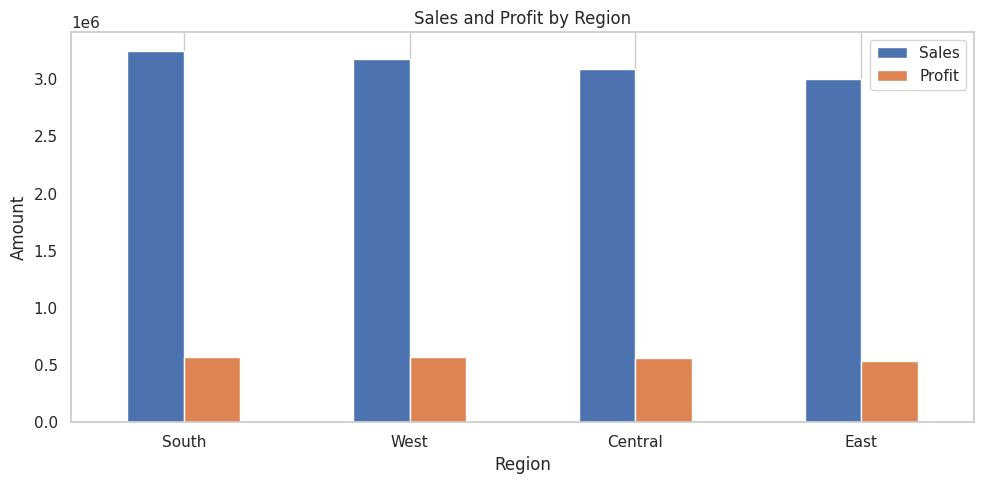

In [20]:
region_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [23]:
# Region-wise Sales and Profit

region_summary = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

display(region_summary)

,Sales,Profit
Region,,
South,3247440.79,574301.38
West,3175737.09,569469.81
Central,3084820.38,558202.61
East,2998817.25,537737.33


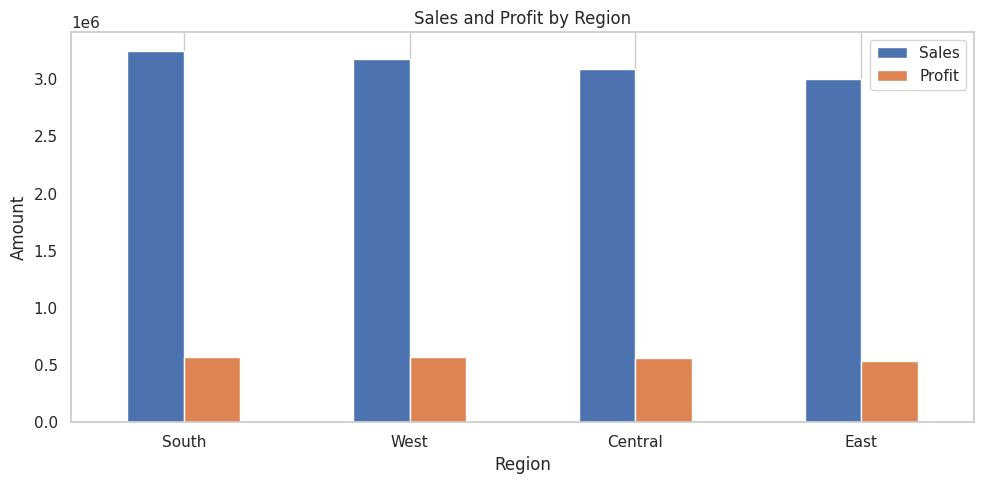

In [24]:
region_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [25]:
# Segment-wise Sales and Profit

segment_summary = (
    df.groupby("Segment")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

display(segment_summary)

,Sales,Profit
Segment,,
Corporate,4244266.85,732570.05
Home Office,4136313.47,775561.84
Consumer,4126235.19,731579.24


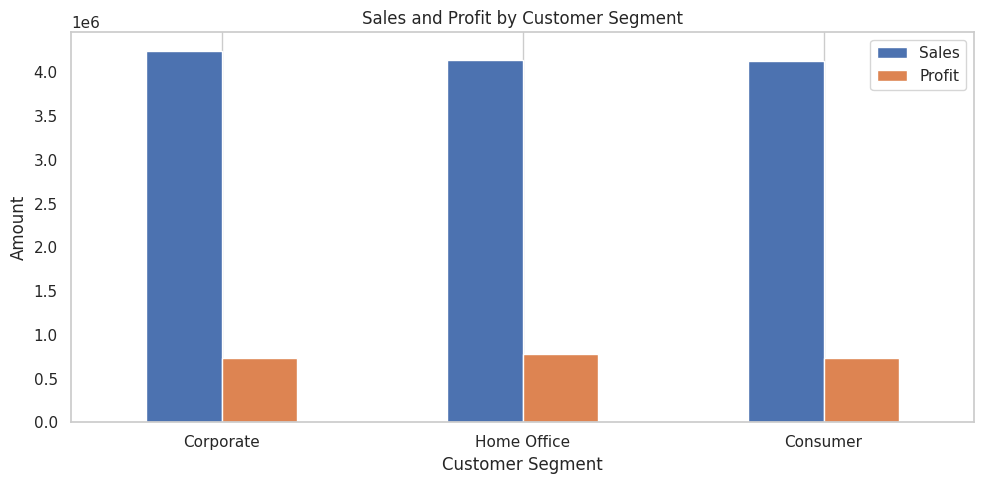

In [26]:
segment_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [27]:
# Top 10 Products by Sales

product_summary = (
    df.groupby("Product Name")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

display(product_summary.head(10))

,Sales,Profit
Product Name,,
Public-key analyzing support,8517.95,1215.48
Cross-platform holistic customer loyalty,7470.21,623.43
Organic heuristic focus group,6368.44,597.32
Quality-focused didactic frame,6296.36,987.38
Organized multi-state approach,5868.48,1378.58
Managed upward-trending Local Area Network,5596.50,255.39
Universal intangible implementation,5195.60,850.89
Enhanced global analyzer,5143.27,1724.52
Self-enabling homogeneous hierarchy,4997.57,339.64


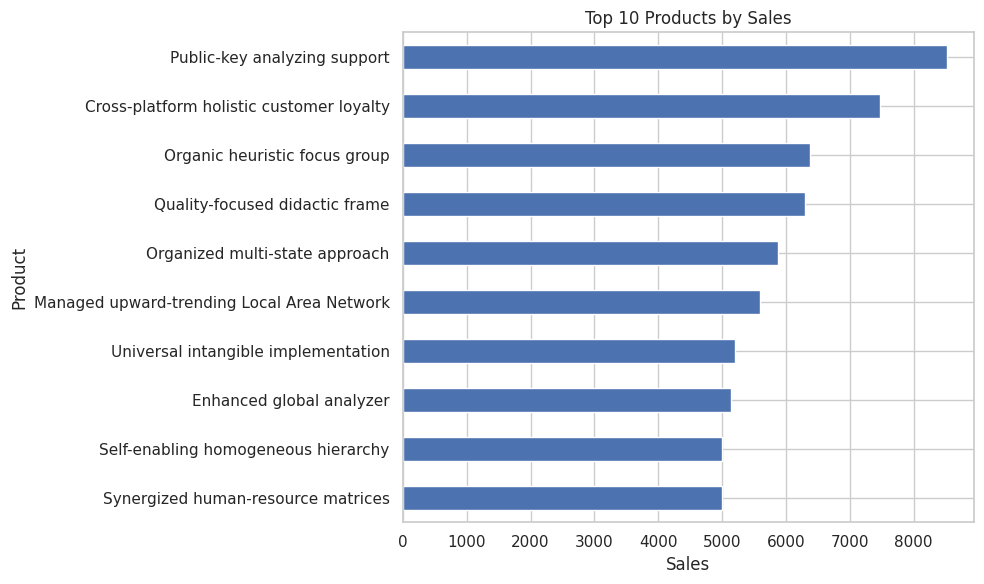

In [28]:
# Top 10 Products Sales Chart

top_products = product_summary.head(10)["Sales"].sort_values()

top_products.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [29]:
# Discount vs Profit

discount_summary = (
    df.groupby("Discount")[["Sales", "Profit", "Quantity"]]
      .sum()
      .sort_index()
)

display(discount_summary)

,Sales,Profit,Quantity
Discount,,,
0.00,156362.72,19333.12,268
0.01,297460.75,53295.19,604
0.02,217955.73,41481.13,510
0.03,248105.62,40350.27,587
0.04,271637.50,49624.31,554
0.05,293996.51,56173.70,605
0.06,211428.30,38769.63,511
0.07,271667.51,44689.42,591
0.08,236464.66,47972.35,536


In [30]:
# Calculate overall profit margin

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Overall Profit Margin:", round(profit_margin, 2), "%")

Total Sales: 12506815.51
Total Profit: 2239711.13
Overall Profit Margin: 17.91 %


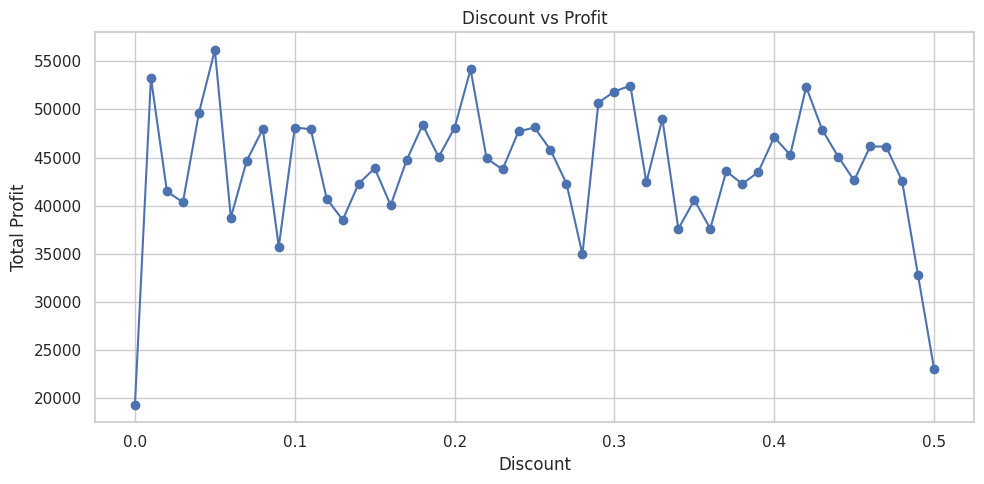

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    discount_summary.index,
    discount_summary["Profit"],
    marker="o"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
# Products with negative total profit

loss_products = (
    df.groupby("Product Name")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit")
)

print("Top 10 Products with Lowest Profit:")
display(loss_products.head(10))

Top 10 Products with Lowest Profit:


,Sales,Profit
Product Name,,
Managed impactful budgetary management,3496.66,-99.96
Quality-focused 3rdgeneration budgetary management,4577.46,-99.92
Progressive empowering alliance,716.24,-99.86
Synergized composite secured line,41.25,-99.85
Business-focused local structure,1524.31,-99.69
Mandatory 4thgeneration budgetary management,446.64,-99.13
Implemented tangible workforce,992.54,-99.08
Realigned maximized array,4193.94,-99.01
Universal secondary database,3366.54,-98.75


In [33]:
# Top 10 Most Profitable Products

top_profit_products = (
    df.groupby("Product Name")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit", ascending=False)
      .head(10)
)

display(top_profit_products)

,Sales,Profit
Product Name,,
Proactive upward-trending methodology,2150.37,1763.49
Enhanced global analyzer,5143.27,1724.52
Organized multi-state approach,5868.48,1378.58
Team-oriented dynamic superstructure,3661.19,1364.58
Universal fresh-thinking contingency,3881.02,1283.97
Public-key analyzing support,8517.95,1215.48
Operative encompassing matrix,1362.74,1074.56
Universal global infrastructure,30.97,999.77
Enterprise-wide multi-tasking policy,1808.76,999.00


In [34]:
# KPI Summary

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
total_quantity = df["Quantity"].sum()
profit_margin = (total_profit / total_sales) * 100

print("========== BUSINESS KPI SUMMARY ==========")
print("Total Sales       :", round(total_sales, 2))
print("Total Profit      :", round(total_profit, 2))
print("Total Orders      :", total_orders)
print("Total Customers   :", total_customers)
print("Total Quantity    :", total_quantity)
print("Profit Margin     :", round(profit_margin, 2), "%")

========== BUSINESS KPI SUMMARY ==========
Total Sales       : 12506815.51
Total Profit      : 2239711.13
Total Orders      : 5000
Total Customers   : 3853
Total Quantity    : 27507
Profit Margin     : 17.91 %


In [35]:
# Best and Worst Performing Categories

category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print("Most Profitable Category:")
print(category_profit.index[0], "->", round(category_profit.iloc[0], 2))

print("\nLeast Profitable Category:")
print(category_profit.index[-1], "->", round(category_profit.iloc[-1], 2))

Most Profitable Category:
Office Supplies -> 754427.39

Least Profitable Category:
Technology -> 731460.46


In [36]:
# Best and Worst Performing Regions

region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print("Most Profitable Region:")
print(region_profit.index[0], "->", round(region_profit.iloc[0], 2))

print("\nLeast Profitable Region:")
print(region_profit.index[-1], "->", round(region_profit.iloc[-1], 2))

Most Profitable Region:
South -> 574301.38

Least Profitable Region:
East -> 537737.33


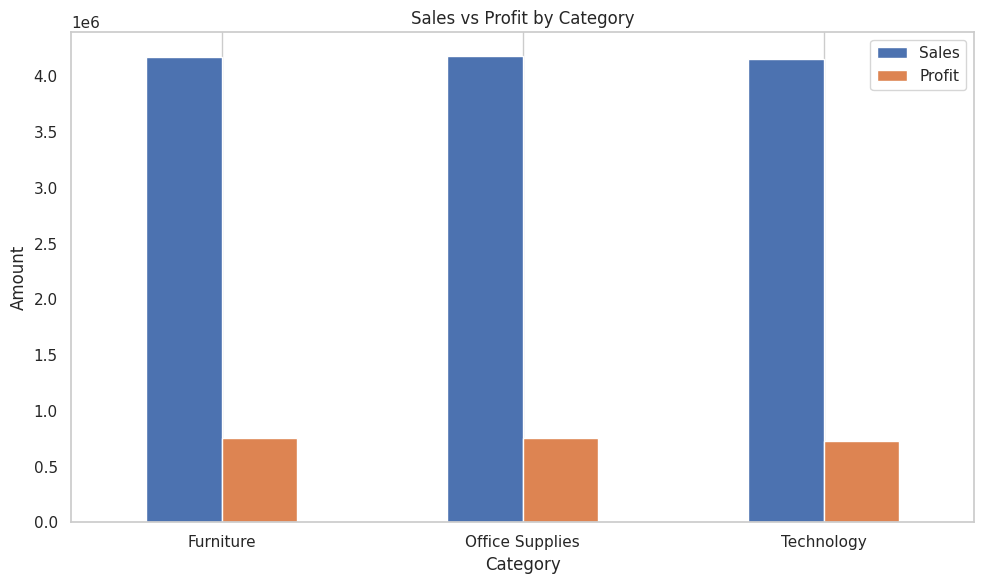

In [37]:
# Sales vs Profit by Category

category_data = df.groupby("Category")[["Sales", "Profit"]].sum()

ax = category_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [38]:
# Category Profit Margin

category_margin = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
)

category_margin["Profit Margin %"] = (
    category_margin["Profit"] /
    category_margin["Sales"]
) * 100

category_margin = category_margin.sort_values(
    "Profit Margin %",
    ascending=False
)

display(category_margin)

,Sales,Profit,Profit Margin %
Category,,,
Furniture,4169553.39,753823.28,18.079233
Office Supplies,4184882.48,754427.39,18.027445
Technology,4152379.64,731460.46,17.615452


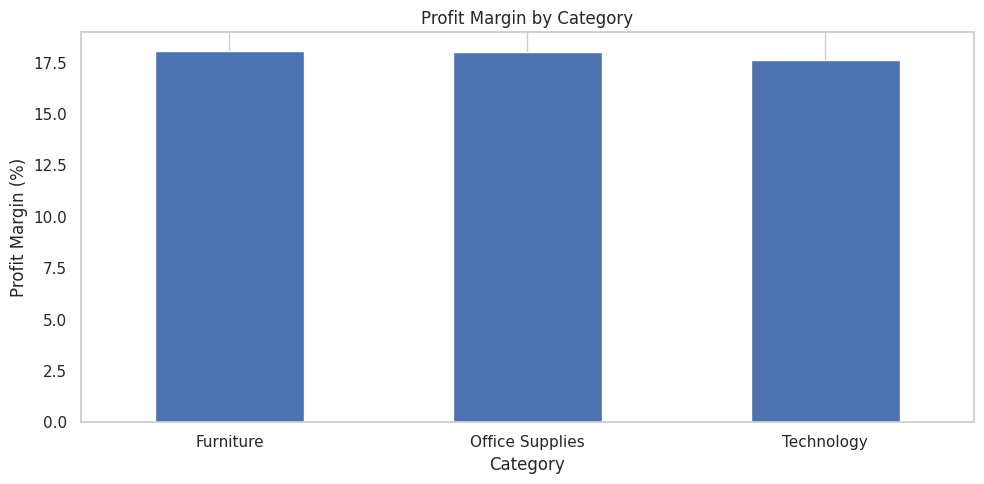

In [39]:
category_margin["Profit Margin %"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [40]:
# Final Business Insights

best_category = category_profit.idxmax()
worst_category = category_profit.idxmin()

best_region = region_profit.idxmax()
worst_region = region_profit.idxmin()

best_product = product_summary["Profit"].idxmax()
worst_product = product_summary["Profit"].idxmin()

best_segment = segment_summary["Profit"].idxmax()
worst_segment = segment_summary["Profit"].idxmin()

print("========== FINAL BUSINESS INSIGHTS ==========")

print("\nBest Category:")
print(best_category)

print("\nLowest Profit Category:")
print(worst_category)

print("\nBest Region:")
print(best_region)

print("\nLowest Profit Region:")
print(worst_region)

print("\nMost Profitable Product:")
print(best_product)

print("\nLeast Profitable Product:")
print(worst_product)

print("\nMost Profitable Customer Segment:")
print(best_segment)

print("\nLeast Profitable Customer Segment:")
print(worst_segment)

========== FINAL BUSINESS INSIGHTS ==========

Best Category:
Office Supplies

Lowest Profit Category:
Technology

Best Region:
South

Lowest Profit Region:
East

Most Profitable Product:
Proactive upward-trending methodology

Least Profitable Product:
Managed impactful budgetary management

Most Profitable Customer Segment:
Home Office

Least Profitable Customer Segment:
Consumer


In [41]:
# Create final summary table

final_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Total Quantity",
        "Profit Margin",
        "Best Category",
        "Best Region",
        "Best Customer Segment",
        "Most Profitable Product"
    ],
    "Value": [
        round(total_sales, 2),
        round(total_profit, 2),
        total_orders,
        total_customers,
        total_quantity,
        f"{profit_margin:.2f}%",
        best_category,
        best_region,
        best_segment,
        best_product
    ]
})

display(final_summary)

,Metric,Value
0,Total Sales,12506815.51
1,Total Profit,2239711.13
2,Total Orders,5000
3,Total Customers,3853
4,Total Quantity,27507
5,Profit Margin,17.91%
6,Best Category,Office Supplies
7,Best Region,South
8,Best Customer Segment,Home Office
9,Most Profitable Product,Proactive upward-trending methodology


In [42]:
# Save cleaned dataset

df.to_csv("superstore_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [43]:
# Monthly Sales Growth

monthly_summary["Sales Growth %"] = (
    monthly_summary["Sales"].pct_change() * 100
)

display(monthly_summary)

,Year,Month,Month Name,Sales,Profit,Sales Growth %
0,2023,4,April,311803.52,62545.60,NaN
1,2023,5,May,555036.79,103807.93,78.008507
2,2023,6,June,544499.85,100714.10,-1.898422
3,2023,7,July,592283.63,93565.20,8.775720
4,2023,8,August,595341.42,113675.34,0.516271
5,2023,9,September,436713.11,84983.15,-26.644931
6,2023,10,October,587824.44,102295.75,34.601968
7,2023,11,November,467392.43,91421.14,-20.487751
8,2023,12,December,509486.38,97810.80,9.006126
9,2024,1,January,475892.06,76370.83,-6.593762


In [44]:
best_sales_month = monthly_summary.loc[
    monthly_summary["Sales"].idxmax()
]

print("Best Sales Month:")
print(best_sales_month["Month Name"], best_sales_month["Year"])
print("Sales:", round(best_sales_month["Sales"], 2))

Best Sales Month:
August 2023
Sales: 595341.42


In [46]:
# High Discount Transactions

high_discount = df[df["Discount"] >= 0.30]

print("Transactions with 30% or higher discount:", len(high_discount))

print("\nSales from high-discount transactions:",
      round(high_discount["Sales"].sum(), 2))

print("Profit from high-discount transactions:",
      round(high_discount["Profit"].sum(), 2))

Transactions with 30% or higher discount: 2047

Sales from high-discount transactions: 5111555.8
Profit from high-discount transactions: 911982.12


In [47]:
if high_discount["Profit"].sum() < 0:
    print("\n⚠️ High discounts are generating an overall loss.")
else:
    print("\nHigh-discount transactions are generating an overall profit.")


High-discount transactions are generating an overall profit.


In [48]:
# Products with negative profit

loss_products = (
    df.groupby("Product Name")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit")
)

negative_products = loss_products[
    loss_products["Profit"] < 0
]

print("Number of loss-making products:",
      len(negative_products))

display(negative_products.head(10))

Number of loss-making products: 473


,Sales,Profit
Product Name,,
Managed impactful budgetary management,3496.66,-99.96
Quality-focused 3rdgeneration budgetary management,4577.46,-99.92
Progressive empowering alliance,716.24,-99.86
Synergized composite secured line,41.25,-99.85
Business-focused local structure,1524.31,-99.69
Mandatory 4thgeneration budgetary management,446.64,-99.13
Implemented tangible workforce,992.54,-99.08
Realigned maximized array,4193.94,-99.01
Universal secondary database,3366.54,-98.75


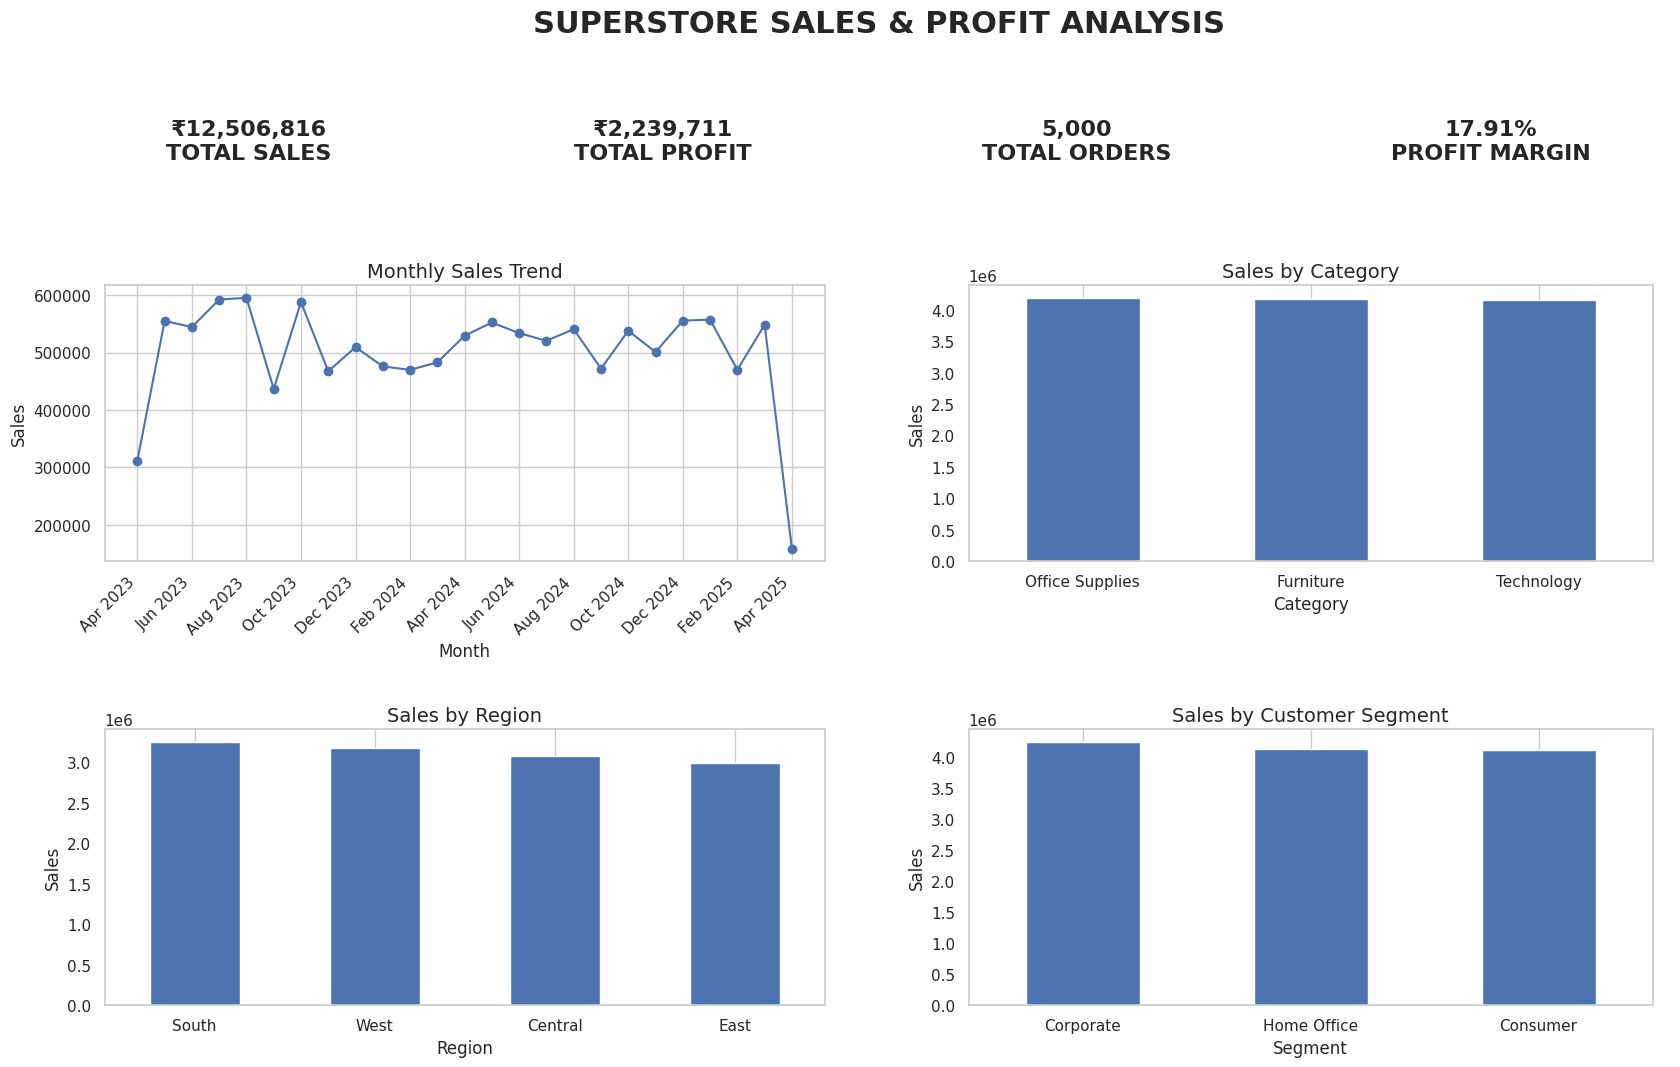

In [50]:
# ==============================
# SUPERSTORE SALES DASHBOARD
# ==============================

import matplotlib.pyplot as plt
import pandas as pd

# KPI calculations
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
profit_margin = (total_profit / total_sales) * 100

# Prepare data
monthly = (
    df.groupby(["Year", "Month", "Month Name"])[["Sales", "Profit"]]
      .sum()
      .reset_index()
      .sort_values(["Year", "Month"])
)

category = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

region = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

segment = (
    df.groupby("Segment")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

# Create dashboard
fig = plt.figure(figsize=(18, 12))

# Main title
fig.suptitle(
    "SUPERSTORE SALES & PROFIT ANALYSIS",
    fontsize=22,
    fontweight="bold"
)

# ---------------- KPI SECTION ----------------

ax1 = fig.add_axes([0.05, 0.82, 0.20, 0.10])
ax2 = fig.add_axes([0.28, 0.82, 0.20, 0.10])
ax3 = fig.add_axes([0.51, 0.82, 0.20, 0.10])
ax4 = fig.add_axes([0.74, 0.82, 0.20, 0.10])

for ax in [ax1, ax2, ax3, ax4]:
    ax.axis("off")

ax1.text(
    0.5, 0.5,
    f"₹{total_sales:,.0f}\nTOTAL SALES",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax2.text(
    0.5, 0.5,
    f"₹{total_profit:,.0f}\nTOTAL PROFIT",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax3.text(
    0.5, 0.5,
    f"{total_orders:,}\nTOTAL ORDERS",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax4.text(
    0.5, 0.5,
    f"{profit_margin:.2f}%\nPROFIT MARGIN",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

# ---------------- MONTHLY SALES ----------------

ax5 = fig.add_axes([0.07, 0.52, 0.40, 0.23])

ax5.plot(
    range(len(monthly)),
    monthly["Sales"],
    marker="o"
)

ax5.set_title("Monthly Sales Trend", fontsize=14)
ax5.set_xlabel("Month")
ax5.set_ylabel("Sales")
ax5.grid(True)

# Show fewer labels if many months
step = max(1, len(monthly) // 10)

ax5.set_xticks(range(0, len(monthly), step))
ax5.set_xticklabels(
    [
        f"{monthly.iloc[i]['Month Name'][:3]} {int(monthly.iloc[i]['Year'])}"
        for i in range(0, len(monthly), step)
    ],
    rotation=45,
    ha="right"
)

# ---------------- CATEGORY ----------------

ax6 = fig.add_axes([0.55, 0.52, 0.38, 0.23])

category["Sales"].plot(
    kind="bar",
    ax=ax6
)

ax6.set_title("Sales by Category", fontsize=14)
ax6.set_xlabel("Category")
ax6.set_ylabel("Sales")
ax6.tick_params(axis="x", rotation=0)
ax6.grid(axis="y")

# ---------------- REGION ----------------

ax7 = fig.add_axes([0.07, 0.15, 0.40, 0.23])

region["Sales"].plot(
    kind="bar",
    ax=ax7
)

ax7.set_title("Sales by Region", fontsize=14)
ax7.set_xlabel("Region")
ax7.set_ylabel("Sales")
ax7.tick_params(axis="x", rotation=0)
ax7.grid(axis="y")

# ---------------- CUSTOMER SEGMENT ----------------

ax8 = fig.add_axes([0.55, 0.15, 0.38, 0.23])

segment["Sales"].plot(
    kind="bar",
    ax=ax8
)

ax8.set_title("Sales by Customer Segment", fontsize=14)
ax8.set_xlabel("Segment")
ax8.set_ylabel("Sales")
ax8.tick_params(axis="x", rotation=0)
ax8.grid(axis="y")

plt.savefig(
    "superstore_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
plt.savefig(
    "superstore_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

print("Dashboard saved successfully!")

Dashboard saved successfully!


<Figure size 640x480 with 0 Axes>

In [52]:
from google.colab import files

files.download("superstore_dashboard.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>